<p align="center"><b><span style="color:red;">Analyse et visualisation des données de FROODIES</span></b></p>


In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

In [27]:
plt.style.use('default')  # Style de base
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.grid'] = True 
orange_palette = sns.color_palette(["#FF7F0E", "#FFA54F", "#FF8C00", "#FF4500", "#FFA500"])
sns.set_palette(orange_palette)
sns.set_style("whitegrid")
plotly_colors = ["#FF7F0E", "#FFA54F", "#FF8C00", "#FF4500", "#FFA500", "#FFD700", "#DAA520", "#D2691E"]
pd.set_option('display.max_columns', None)

In [28]:
# Lecture des données
df = pd.read_csv('paris_restaurants_5000.csv')

<p><b style="color:black;">1. Information de base sur le dataset</b></p>

In [29]:
print(f"Nombre de restaurants: {len(df)}")
print("\nPremières lignes du dataset:")
df.head()

Nombre de restaurants: 5000

Premières lignes du dataset:


,nom,adresse,arrondissement,latitude,longitude,type_cuisine,specialite,prix_fourchette,categorie_prix,note_moyenne,nb_avis,ambiance,telephone,reservation_recommandee
0,Bistrot Nouveau Gourmand,"36 boulevard Haussmann, 75018 Paris",75018,48.837475,2.350175,Grecque,Végan,20-30,Moyenne gamme,3.5,626,Romantique,181359399,False
1,Laurent,"41 rue du Temple, 75014 Paris",75014,48.924054,2.341159,Indien,Sushi,30-50,Moyenne gamme,3.2,399,Cosy,155548743,False
2,Paris & Moulin,"21 rue Vaugirard, 75010 Paris",75010,48.945404,2.397302,Street food,NaN,30-50,Moyenne gamme,4.2,731,Branché,115943947,False
3,Hubert & Joly,"72 rue Didot, 75012 Paris",75012,48.908800,2.344681,Vietnamien,Pizza,10-20,Bon marché,4.2,185,Calme,130695844,False
4,Les Gallet,"15 rue Lepic, 75002 Paris",75002,48.845030,2.291927,Bistrot,Marocain,100+,Haut de gamme,4.8,332,Animé,193736092,True


In [30]:
print("\nValeurs manquantes par colonne:")
print(df.isnull().sum())


Valeurs manquantes par colonne:
nom                           0
adresse                       0
arrondissement                0
latitude                      0
longitude                     0
type_cuisine                  0
specialite                 1529
prix_fourchette               0
categorie_prix                0
note_moyenne                  0
nb_avis                       0
ambiance                      0
telephone                     0
reservation_recommandee       0
dtype: int64


In [31]:
print("\nStatistiques descriptives:")
df.describe()


Statistiques descriptives:


,arrondissement,latitude,longitude,note_moyenne,nb_avis,telephone
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5.000000e+03
mean,75010.504200,48.884322,2.335796,3.992320,500.424000,1.549276e+08
std,5.815801,0.049196,0.048568,0.581244,287.413315,2.600678e+07
min,75001.000000,48.800018,2.250042,3.000000,10.000000,1.101079e+08
25%,75005.000000,48.841725,2.294071,3.500000,250.000000,1.326510e+08
50%,75010.000000,48.883949,2.336890,4.000000,498.000000,1.544984e+08
75%,75016.000000,48.926995,2.377909,4.500000,750.000000,1.772859e+08
max,75020.000000,48.969970,2.419970,5.000000,1000.000000,1.999788e+08


<p><b style="color:black;">Visualisation 1 : Répartition des restaurants par arrondissement</b></p>

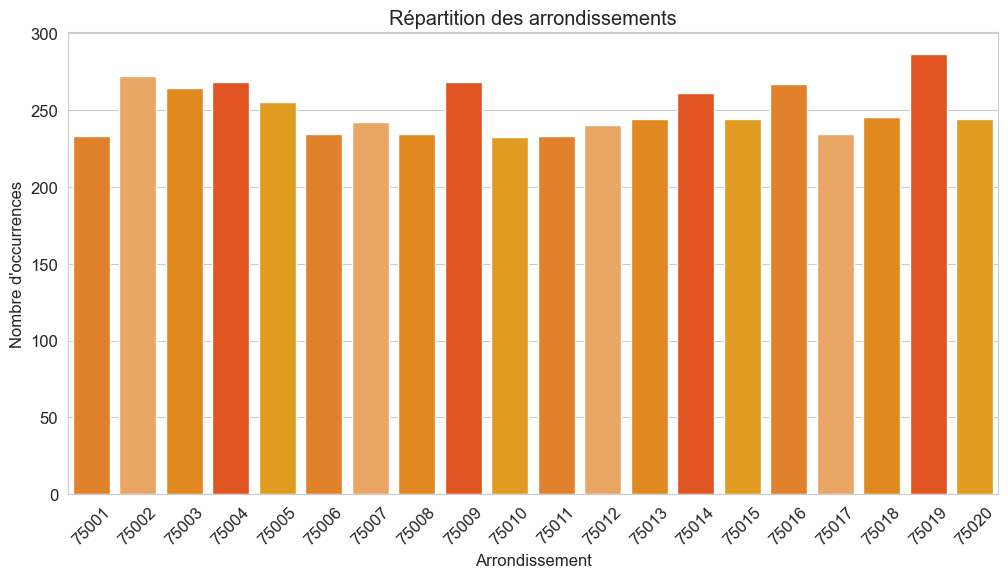

In [34]:
arr_counts = df["arrondissement"].value_counts().sort_index()

# Création du graphique
plt.figure(figsize=(12, 6))
sns.barplot(x=arr_counts.index, y=arr_counts.values, palette=orange_palette)
plt.xlabel("Arrondissement")
plt.ylabel("Nombre d'occurrences")
plt.title("Répartition des arrondissements")
plt.xticks(rotation=45)
plt.show()

<p><b style="color:black;">Visualisation 2 : Distribution des notes moyennes </b></p>

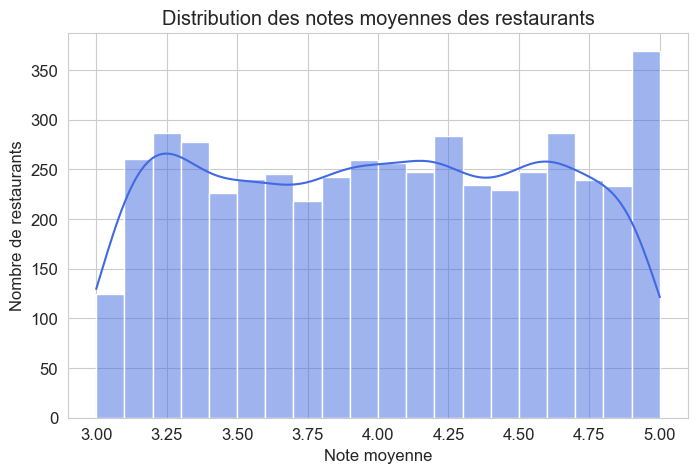

In [43]:
plt.figure(figsize=(8, 5))
sns.histplot(df["note_moyenne"], bins=20, kde=True, color="royalblue")
plt.title("Distribution des notes moyennes des restaurants")
plt.xlabel("Note moyenne")
plt.ylabel("Nombre de restaurants")
plt.show()

<p><b style="color:black;">Visualisation 3 : Répartition des gammes de prix  </b></p>

In [45]:
fig = px.pie(df, names="categorie_prix", title="Répartition des restaurants par gamme de prix", hole=0.3)
fig.show()

<p><b style="color:black;">Visualisation 4 : Boxplot des notes par gamme de prix  </b></p>

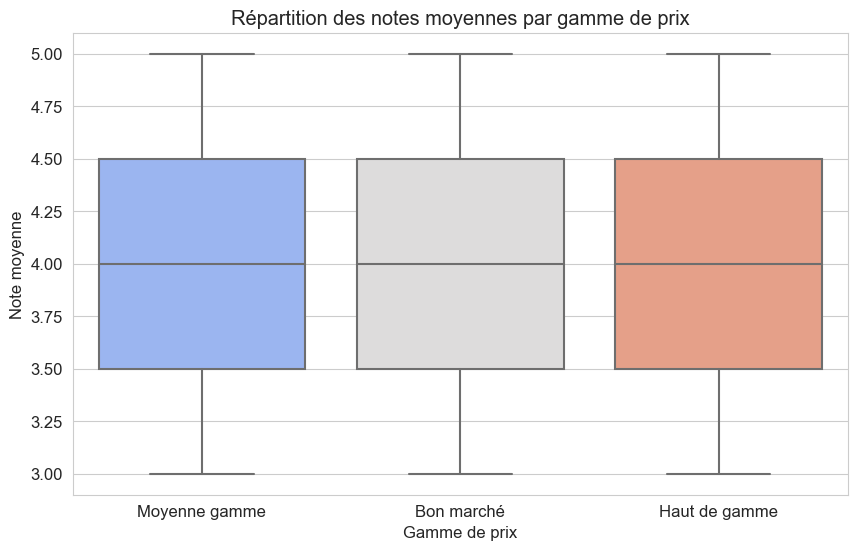

In [47]:
plt.figure(figsize=(10, 6))
sns.boxplot(x="categorie_prix", y="note_moyenne", data=df, palette="coolwarm")
plt.title("Répartition des notes moyennes par gamme de prix")
plt.xlabel("Gamme de prix")
plt.ylabel("Note moyenne")
plt.show()

<p><b style="color:black;">Visualisation 6 : Heatmap des types de cuisine par arrondissement</b></p>

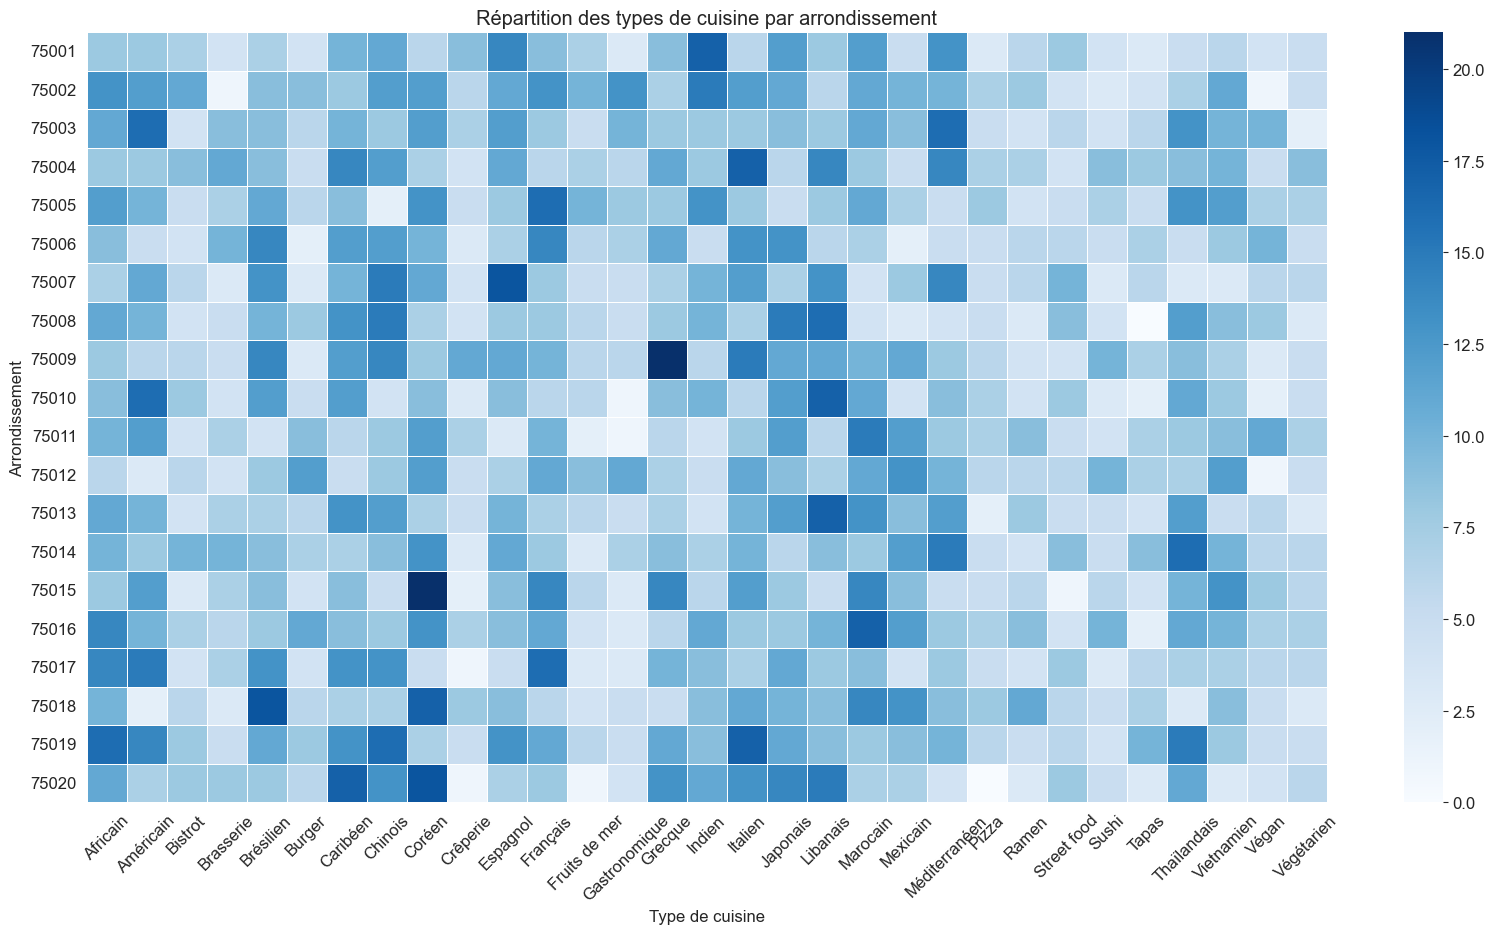

In [52]:
pivot_table = df.pivot_table(index="arrondissement", columns="type_cuisine", aggfunc="size", fill_value=0)
plt.figure(figsize=(20, 10))
sns.heatmap(pivot_table, cmap="Blues", linewidths=0.5)
plt.title("Répartition des types de cuisine par arrondissement")
plt.xlabel("Type de cuisine")
plt.ylabel("Arrondissement")
plt.xticks(rotation=45)
plt.show()